# Rock-Paper-Scissors - Inference 

**Goal.** Take the model trained in `dl-v1.ipynb` (saved as `rps_cnn.keras`) and use it to classify new images - one at a time, in batches, and from a folder.

**What you'll learn:**
1. The mental separation between *training* (does my model learn?) and *inference* (does my model serve?).
2. How to load a `.keras` model in one line and verify it's the right one.
3. The minimum preprocessing pipeline at inference time, and why **it must mirror training**.
4. How to read raw `softmax` outputs into class names, top-K predictions, and confidences.
5. How to run inference on a whole folder efficiently with `tf.data`.
6. Common production pitfalls (image size, channel order, missing rescale).

...

> **One-line summary of the contract.** *The pre-processing your inference code does to a new image must produce a tensor that looks identical, statistically, to what your `model.fit(...)` saw.*


## 0. Imports


In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import keras
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'Keras : {keras.__version__}')


2026-05-04 17:34:20.065688: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow : 2.16.2
Keras : 3.14.0


## 1. Load the trained model

`keras.saving.load_model` reads the `.keras` archive and rebuilds the full model: architecture **plus** weights **plus** optimiser state. We don't need the optimiser for inference, but it costs almost nothing and lets you resume training later.

After loading, **always call `model.summary()`** to verify it is the network you think it is. A common production bug is silently loading a stale checkpoint.


In [2]:
MODEL_PATH = 'rps_cnn.keras'

model = keras.saving.load_model(MODEL_PATH)
model.summary()

Model: "rps_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,705,355 (17.95 MB)

 Trainable params: 1,568,451 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,136,904 (11.97 MB)

## 2. Class names and the inference contract

The model outputs a probability vector of length `num_classes`. To map indices -> human-readable labels we keep the same `class_names` list that `image_dataset_from_directory` produced during training, **in the same alphabetical order**.

> **Production tip.** Don't hard-code class names in two places. Save them next to the model (`json`, `txt`, or as part of the model's metadata) and load them with the model. We hard-code here only because it's a small project.

**`IMAGE_SIZE` must match training.** If training used 150×150, inference must too. The `Rescaling(1/255)` layer is *inside* the model graph (we put it there in v1), so we do **not** divide by 255 again here - that would be a double-rescale and the model would see effectively-black images.


In [3]:
CLASS_NAMES = ['paper', 'rock', 'scissors']     # alphabetical, same as training
IMAGE_SIZE  = (150, 150)                        # MUST match the training image size

## 3. Helper: predict on a single image path

We wrap the four steps of inference (`load -> to-array -> add batch dim -> predict`) into one function. This makes the rest of the notebook a series of one-liners.

**Step-by-step:**
1. **Load and resize.** `keras.utils.load_img(path, target_size=(H, W))` returns a PIL image already at the right size, in RGB.
2. **PIL -> numpy.** `keras.utils.img_to_array` returns a `float32` array of shape `(H, W, 3)` with values in `[0, 255]`.
3. **Add batch dim.** Keras models always expect a leading batch axis. `np.expand_dims(x, 0)` (or `tf.expand_dims`) turns `(H, W, 3)` into `(1, H, W, 3)`.
4. **Predict.** `model.predict(x)` returns a `(1, num_classes)` softmax. `[0]` strips the batch dim.


In [ ]:
def predict_image(model, img_path, image_size=IMAGE_SIZE, class_names=CLASS_NAMES):
    """Run the model on a single image file. Returns (label, confidence, probs)."""
    img = keras.utils.load_img(img_path, target_size=image_size)
    img_array = keras.utils.img_to_array(img)
    batch = np.expand_dims(img_array, axis=0)             # (1, H, W, 3)

    probs = model.predict(batch, verbose=0)[0]            # (num_classes,)
    idx = int(np.argmax(probs))
    
    return class_names[idx], float(probs[idx]), probs

## 4. Predict on a single image

Replace `IMG_PATH` with any RPS image you have. The cell below shows the image, the predicted label, the confidence, and a horizontal bar of probabilities for *all* classes - the full picture, not just `argmax`.


In [5]:
IMG_PATH = 'paper01-000.png'    # change me

label, conf, probs = predict_image(model, IMG_PATH)

print(f'predicted : {label}')
print(f'confidence: {conf*100:.2f}%')
print('all probs :')
for name, p in zip(CLASS_NAMES, probs):
    print(f'  {name:<10} {p*100:6.2f}%')

predicted : paper
confidence: 100.00%
all probs :
  paper      100.00%
  rock         0.00%
  scissors     0.00%


### 4.1 Visualise: image + probability bar


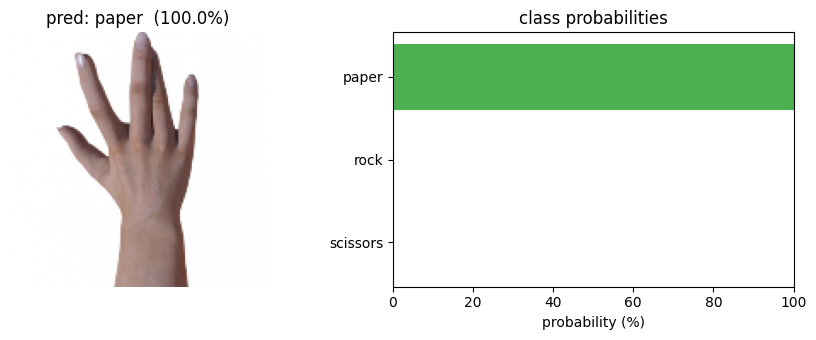

In [6]:
img = keras.utils.load_img(IMG_PATH, target_size=IMAGE_SIZE)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(img)
axes[0].set_title(f'pred: {label}  ({conf*100:.1f}%)')
axes[0].axis('off')

y_pos = np.arange(len(CLASS_NAMES))
colors = ['#4caf50' if i == np.argmax(probs) else '#bdbdbd' for i in y_pos]
axes[1].barh(y_pos, probs * 100, color=colors)
axes[1].set_yticks(y_pos, labels=CLASS_NAMES)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('probability (%)')
axes[1].invert_yaxis()
axes[1].set_title('class probabilities')
plt.tight_layout()
plt.show()

## 5. Top-K predictions

For any classifier with more than a handful of classes, **top-K accuracy** is more informative than top-1. With just 3 classes it's a bit overkill, but the pattern is the same one ImageNet evaluators use.


In [7]:
def top_k(probs, class_names, k=3):
    idx = np.argsort(probs)[::-1][:k]
    return [(class_names[i], float(probs[i])) for i in idx]

for name, p in top_k(probs, CLASS_NAMES, k=3):
    print(f'{name:<10} {p*100:6.2f}%')

paper      100.00%
scissors     0.00%
rock         0.00%


## 6. Batch inference on a folder

Calling `predict_image` in a Python `for` loop is fine for one image, but slow for hundreds: each call runs its own forward pass with batch-size 1 and pays per-call overhead. The fast pattern is:

1. Build a `tf.data.Dataset` of file paths.
2. Map a decode-and-resize function over it.
3. Batch.
4. Call `model.predict(ds)` *once* on the whole batched dataset.

This pushes the work into TensorFlow's optimised graph runtime and easily runs 10–100× faster than a Python loop.


In [8]:
def folder_to_dataset(folder, image_size=IMAGE_SIZE, batch_size=32):
    """Load all images in `folder` (non-recursive) into a batched tf.data.Dataset."""
    folder = Path(folder)
    paths  = sorted(str(p) for p in folder.iterdir()
                    if p.suffix.lower() in {'.png', '.jpg', '.jpeg'})

    def _decode(path):
        raw = tf.io.read_file(path)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        img = tf.cast(img, tf.float32)
        return img

    ds = (tf.data.Dataset.from_tensor_slices(paths)
          .map(_decode, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))
    return ds, paths


Now run it. Point `FOLDER` at any directory of RPS images. We'll print a tally of predictions and show a small grid.


In [9]:
# FOLDER = '.'    # any folder containing RPS images — change as needed

# ds, paths = folder_to_dataset(FOLDER)
# if not paths:
#     print(f'No images found in {FOLDER!r}')
# else:
#     probs_batch = model.predict(ds, verbose=0)             # (N, num_classes)
#     pred_idx    = np.argmax(probs_batch, axis=1)
#     pred_conf   = np.max(probs_batch, axis=1)

#     # tally
#     print(f'Ran inference on {len(paths)} images.\n')
#     for i, name in enumerate(CLASS_NAMES):
#         n = int((pred_idx == i).sum())
#         print(f'  {name:<10} {n:4d}')


### 6.1 Show a grid of predictions


In [10]:
# if paths:
#     n_show = min(12, len(paths))
#     plt.figure(figsize=(12, 8))
#     for i in range(n_show):
#         ax = plt.subplot(3, 4, i + 1)
#         plt.imshow(keras.utils.load_img(paths[i], target_size=IMAGE_SIZE))
#         ax.set_title(f'{CLASS_NAMES[pred_idx[i]]}  ({pred_conf[i]*100:.0f}%)', fontsize=10)
#         plt.axis('off')
#     plt.tight_layout()
#     plt.show()

## 7. Common inference pitfalls (and how to spot them)

| symptom                                         | likely cause                                                                                                  | fix                                                                            |
|-------------------------------------------------|---------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| Confidence ≈ 33% on every image (uniform)       | image fed to the model is essentially black (e.g. you divided by 255 *and* the model already does it inside)  | Don't pre-rescale if `Rescaling` is part of the model graph                     |
| Wrong predictions but high confidence           | image size mismatch — model was trained on 150×150 and you passed 224×224                                     | Always resize to the training `IMAGE_SIZE`                                      |
| Inverted colours                                | OpenCV (BGR) vs Keras/PIL (RGB) order mismatch                                                                | Use `keras.utils.load_img` *or* convert with `cv2.cvtColor(img, COLOR_BGR2RGB)` |
| Predictions shift after retraining              | class indexing changed because a new folder was added / removed                                               | Persist `class_names` next to the model, don't hard-code                        |
| Slow batch inference                            | Python `for` loop calling `model.predict` per image                                                           | Use a `tf.data.Dataset` + a single `model.predict(ds)` call                     |

**Sanity check you should run after any change to preprocessing:** pick a handful of training images you *know* the label of, run them through your inference function, and confirm the predictions match. If they don't, the inference pipeline diverges from training somehow.


## 8. Where to go next

1. **Wrap this notebook into a service.** Move `predict_image` into a `predict.py` module, expose it behind a FastAPI endpoint, and you have a tiny model server.
2. **Convert to a lighter format.** `tf.lite.TFLiteConverter` for mobile, ONNX for cross-framework, TensorRT for GPU servers.
3. **Confidence calibration.** Raw softmax is over-confident. Look at *temperature scaling* if you need the probabilities to mean something quantitative.
4. **Logging.** In production, log `(input_hash, prediction, confidence, latency)` for every request. It's the only way to detect data drift early.
